In [2]:
%load_ext autoreload
%autoreload 2

import sqlite3
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
from datetime import datetime
from order_fingers import TouchTracker
import matplotlib.pyplot as plt
import warnings
import itertools
from itertools import combinations
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

np.random.seed(42)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
DB_PATH = "./labeled_new.sqlite"

SENSOR_COLUMNS = [
    'button_pressed',
    'motor_angle',
    'touch_1_position', 'touch_1_pressure', 'touch_1_channel',
    'touch_2_position', 'touch_2_pressure', 'touch_2_channel',
    'touch_3_position', 'touch_3_pressure', 'touch_3_channel',
    'touch_4_position', 'touch_4_pressure', 'touch_4_channel',
    'touch_5_position', 'touch_5_pressure', 'touch_5_channel',
]
TIMESTAMP_COLUMN = 'timestamp_ms'
ID_COLUMNS = ['participant_id', 'session_task_id']
LABEL_COLUMN = 'parent_gesture'

WINDOW_SIZE_SAMPLES = 60
WINDOW_STRIDE_SAMPLES = 20
SAMPLING_RATE_HZ = 70  # in Hz
TOUCH_MOVE_THRESHOLD = 0.01  # Radians
WINDOW_GESTURE_MAJORITY_THRESHOLD = 0.4  # 40%

In [4]:
query = """
WITH start_end_indices AS (
    SELECT
        s.session_task_id,
        s.sensor_data_index AS start_index,
        MIN(e.sensor_data_index) AS next_end_index
    FROM preciseMarker s
    JOIN preciseMarker e 
        ON e.session_task_id = s.session_task_id
       AND e.sensor_data_index > s.sensor_data_index
    WHERE s.marker_type = 'start'
      AND e.marker_type = 'end'
    GROUP BY s.session_task_id, s.sensor_data_index
),
start_marker_timestamps AS (
    SELECT
        sensorData.session_task_id,
        session_task_row_index,
        preciseMarker.id AS group_id
    FROM sensorData
    JOIN preciseMarker
        ON sensorData.session_task_id = preciseMarker.session_task_id
       AND session_task_row_index = preciseMarker.sensor_data_index
    WHERE preciseMarker.marker_type = 'start'
),
session_first_start_last_end AS (
    SELECT
        sei.session_task_id,
        MIN(sei.start_index) AS first_start_index,
        MAX(sei.next_end_index) AS last_end_index
    FROM start_end_indices sei
    GROUP BY sei.session_task_id
),
gesture_samples AS (
    SELECT 
        sd.id,
        sd.session_task_id,
        sd.session_task_row_index,
        sd.timestamp,
        sd.timestamp_ms,
        sd.button_pressed,
        sd.motor_angle,
        sd.touch_1_position,
        sd.touch_1_pressure,
        sd.touch_1_channel,
        sd.touch_2_position,
        sd.touch_2_pressure,
        sd.touch_2_channel,
        sd.touch_3_position,
        sd.touch_3_pressure,
        sd.touch_3_channel,
        sd.touch_4_position,
        sd.touch_4_pressure,
        sd.touch_4_channel,
        sd.touch_5_position,
        sd.touch_5_pressure,
        sd.touch_5_channel,
        rt.title AS gesture,
        CASE WHEN smt.group_id is null THEN 'No Gesture' ELSE rtParent.title END AS parent_gesture,
        s.participant_id,
        CASE WHEN rtParent.title = 'No Gesture' or smt.group_id is null THEN 0 ELSE 1 END AS is_gesture,
        smt.group_id
    FROM sensorData sd
    left JOIN start_end_indices sei
      ON sd.session_task_id = sei.session_task_id
     AND sd.session_task_row_index BETWEEN sei.start_index AND sei.next_end_index
    left JOIN start_marker_timestamps smt
      ON smt.session_task_id = sei.session_task_id
     AND smt.session_task_row_index = sei.start_index
     JOIN session_first_start_last_end sfsle
      ON sd.session_task_id = sfsle.session_task_id
        AND sd.session_task_row_index BETWEEN sfsle.first_start_index AND sfsle.last_end_index
    LEFT JOIN sessionTask st
      ON sd.session_task_id = st.id
    LEFT JOIN session s
      ON st.session_id = s.id
    LEFT JOIN recordingTask rt
      ON st.recording_task_id = rt.id
    LEFT JOIN recordingTask rtParent
      ON rt.parent_id = rtParent.id
    WHERE rtParent.title != 'Szenarien'
)

-- Final combined dataset
SELECT * FROM gesture_samples
ORDER BY session_task_id, session_task_row_index;
"""

with sqlite3.connect(DB_PATH) as conn:
    df_raw = pd.read_sql_query(query, conn)

In [5]:
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'])
df_raw['time_diff'] = df_raw.groupby(['session_task_id', 'timestamp']).cumcount()
df_raw['recordings_per_second'] = df_raw.groupby(['session_task_id', 'timestamp'])['id'].transform('count')
df_raw['estimated_timestamp'] = df_raw['timestamp'] + pd.to_timedelta(df_raw['time_diff'] / df_raw['recordings_per_second'], unit='s')
df_raw = df_raw.drop(columns=['time_diff', 'recordings_per_second'])

df_raw["timestamp_ms"] = (df_raw["estimated_timestamp"].astype(np.int64) // 10**6).astype(np.int64)

In [6]:
df_raw["gesture"] = df_raw["gesture"].astype("category")
df_raw["parent_gesture"] = df_raw["parent_gesture"].astype("category")

In [7]:
is_null = df_raw["group_id"].isnull()
null_block_start = is_null & (~is_null.shift(1, fill_value=False))
block_ids = null_block_start.cumsum()
df_raw["group_id"] = df_raw["group_id"].fillna("no_gesture_block_" + block_ids.astype(str))

In [8]:
def augment_data_all_permutations(df, limit=None):
    augmented_dfs = []

    # All 5! = 120 permutations of touch indices 1..5
    permutations = list(itertools.permutations(range(1, 6)))
    # randomly shuffle the permutations, in case there is a limit set
    if limit is not None:
        np.random.shuffle(permutations)

    for i, perm in enumerate(permutations):
        if limit is not None and i >= limit:
            break

        df_aug = df.copy()

        # Reorder touch columns according to permutation
        for j, new_idx in enumerate(perm, start=1):
            for suffix in ['position', 'pressure', 'channel']:
                df_aug[f'touch_{j}_{suffix}'] = df[f'touch_{new_idx}_{suffix}']

        # Append unique suffix to id fields
        suffix = f'_perm{i}'
        df_aug['id'] = df_aug['id'].astype(str) + suffix
        df_aug['group_id'] = df_aug['group_id'].astype(str) + suffix
        df_aug['session_task_id'] = df_aug['session_task_id'].astype(str) + suffix
        df_aug['participant_id'] = df_aug['participant_id'].astype(str) + suffix

        augmented_dfs.append(df_aug)

    # Original + all permutations
    return pd.concat([df] + augmented_dfs, ignore_index=True)

In [9]:
# Normalize the input data
# 1. Normalize all positions from [0, 2PI] to [0, 1]
for col in SENSOR_COLUMNS:
    if 'position' in col:
        df_raw[col] = df_raw[col] / (2 * np.pi)
# 2. Normalize pressures using min max scaling to [0, 1], per participant
for col in SENSOR_COLUMNS:
    if 'pressure' in col:
        df_raw[col] = df_raw.groupby('participant_id')[col].transform(
            lambda x: (x - x.min()) / (x.max() - x.min())
        )
# 3. Normalize channel values using min max scaling to [0, 1], per participant
for col in SENSOR_COLUMNS:
    if 'channel' in col:
        df_raw[col] = df_raw.groupby('participant_id')[col].transform(
            lambda x: (x - x.min()) / (x.max() - x.min())
        )
# 4. Normalize motor_angle using min max scaling to [0, 1], per participant
df_raw['motor_angle'] = df_raw.groupby('participant_id')['motor_angle'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)       

In [10]:
df_raw[LABEL_COLUMN].value_counts()

parent_gesture
No Gesture                        230485
Pinch Swipe                        12037
Tap and Hold                       11985
Spread Swipe                        9049
Single Swipe                        6072
Two-Finger Opposite Double Tap      3010
Two-Finger Double Tap               3001
Double Tap                          2784
Two-Finger Opposite Tap             1719
Two-Finger Tap                      1646
Single Tap                          1407
Name: count, dtype: int64

In [11]:
# Sort after ID_COLUMNS and TIMESTAMP_COLUMN
df_raw = df_raw.sort_values(by=ID_COLUMNS + [TIMESTAMP_COLUMN]).reset_index(drop=True)

In [12]:
df_raw.groupby(["participant_id"]).size()

participant_id
5d52daf3-c962-4db6-a8f8-298a0bb01733    36375
6331fbd1-76bb-48d6-92a2-80a55a70d134    31589
696b4743-9d39-4fb1-8271-90e7d48652af    21096
6a1b56e6-47ce-43cb-96cb-713d055d8f6d    43728
707c3867-fe15-4b05-bf7b-fc5f3b501fb1    33659
754f0f37-a3b5-4f3d-aaf4-7d4e1a8cafd0    39524
d3b39f0f-b799-4d69-b7a3-a663e5c7438f    35425
fdd02af8-c764-43ba-8247-c612f85568b4    41799
dtype: int64

In [13]:
# Check all columns with nan values
nan_columns = df_raw.columns[df_raw.isna().any()].tolist()
nan_columns

['touch_1_position',
 'touch_1_pressure',
 'touch_1_channel',
 'touch_2_position',
 'touch_2_pressure',
 'touch_2_channel',
 'touch_3_position',
 'touch_3_pressure',
 'touch_3_channel',
 'touch_4_position',
 'touch_4_pressure',
 'touch_4_channel',
 'touch_5_position',
 'touch_5_pressure',
 'touch_5_channel']

In [14]:
import pandas as pd
import numpy as np

TOUCH_COLUMNS_BASE = ['position', 'pressure', 'channel']
MAX_TOUCHES = 5
TOUCH_PREFIXES = [f'touch_{i+1}' for i in range(MAX_TOUCHES)]

def process_and_stabilize_touches(df: pd.DataFrame):
    all_stabilized_rows = []
    active_ids_per_row = []
    
    tracker = TouchTracker() 
    tracker_group_id = None
    
    # id_to_slot_map: {touch_id: slot_index}
    id_to_slot_map = {} 
    # last_seen_in_row: {touch_id: index_of_last_appearance}
    last_seen_in_row = {} 

    for index, row in df.iterrows():
        current_group_id = row.get('session_task_id', None)
        
        if tracker_group_id != current_group_id:
            tracker.clear()
            id_to_slot_map = {}
            last_seen_in_row = {}
            tracker_group_id = current_group_id
        
        # 1. Extract raw touches
        new_touches = []
        for prefix in TOUCH_PREFIXES:
            pos = row[f'{prefix}_position']
            press = row[f'{prefix}_pressure']
            chan = row[f'{prefix}_channel']
            new_touches.append((pos, press, chan))
            
        # 2. Assign IDs via tracker
        matched_touches = tracker.assign_ids(new_touches)
        
        # 3. Handle Slot Mapping with Eviction Logic
        row_slots = [np.nan] * (MAX_TOUCHES * len(TOUCH_COLUMNS_BASE))
        current_row_ids = [t[0] for t in matched_touches]

        for touch in matched_touches:
            tid, touch_data = touch[0], touch[1:]
            last_seen_in_row[tid] = index # Track when we last saw this ID active

            if tid not in id_to_slot_map:
                existing_slots = set(id_to_slot_map.values())
                
                if len(existing_slots) < MAX_TOUCHES:
                    # Case A: Room available, find first empty slot
                    for s_idx in range(MAX_TOUCHES):
                        if s_idx not in existing_slots:
                            id_to_slot_map[tid] = s_idx
                            break
                else:
                    # Case B: Map is full. Find the ID in the map that 
                    # hasn't been seen for the longest time and steal its slot.
                    # This happens if persistence is holding a slot for a finger that isn't there.
                    oldest_tid = min(id_to_slot_map.keys(), key=lambda x: last_seen_in_row.get(x, -1))
                    stolen_slot = id_to_slot_map.pop(oldest_tid)
                    id_to_slot_map[tid] = stolen_slot
                    # Also clean up tracker if we are force-evicting from slot map
                    if oldest_tid in tracker.persistence_buffer:
                        del tracker.persistence_buffer[oldest_tid]
            
            slot = id_to_slot_map[tid]
            start_idx = slot * len(TOUCH_COLUMNS_BASE)
            row_slots[start_idx : start_idx + 3] = touch_data

        # 4. Standard Cleanup: Sync with Tracker's own expiration
        all_remembered_ids = set(tracker.active_touches.keys()) | set(tracker.persistence_buffer.keys())
        ids_to_forget = [tid for tid in id_to_slot_map if tid not in all_remembered_ids]
        for tid in ids_to_forget:
            id_to_slot_map.pop(tid, None)

        all_stabilized_rows.append(row_slots)
        active_ids_per_row.append(current_row_ids)

    # DataFrame creation...
    new_col_names = [f'{p}_{c}' for p in TOUCH_PREFIXES for c in TOUCH_COLUMNS_BASE]
    stabilized_df = pd.DataFrame(all_stabilized_rows, index=df.index, columns=new_col_names)
    stabilized_df['active_ids'] = active_ids_per_row
    return stabilized_df

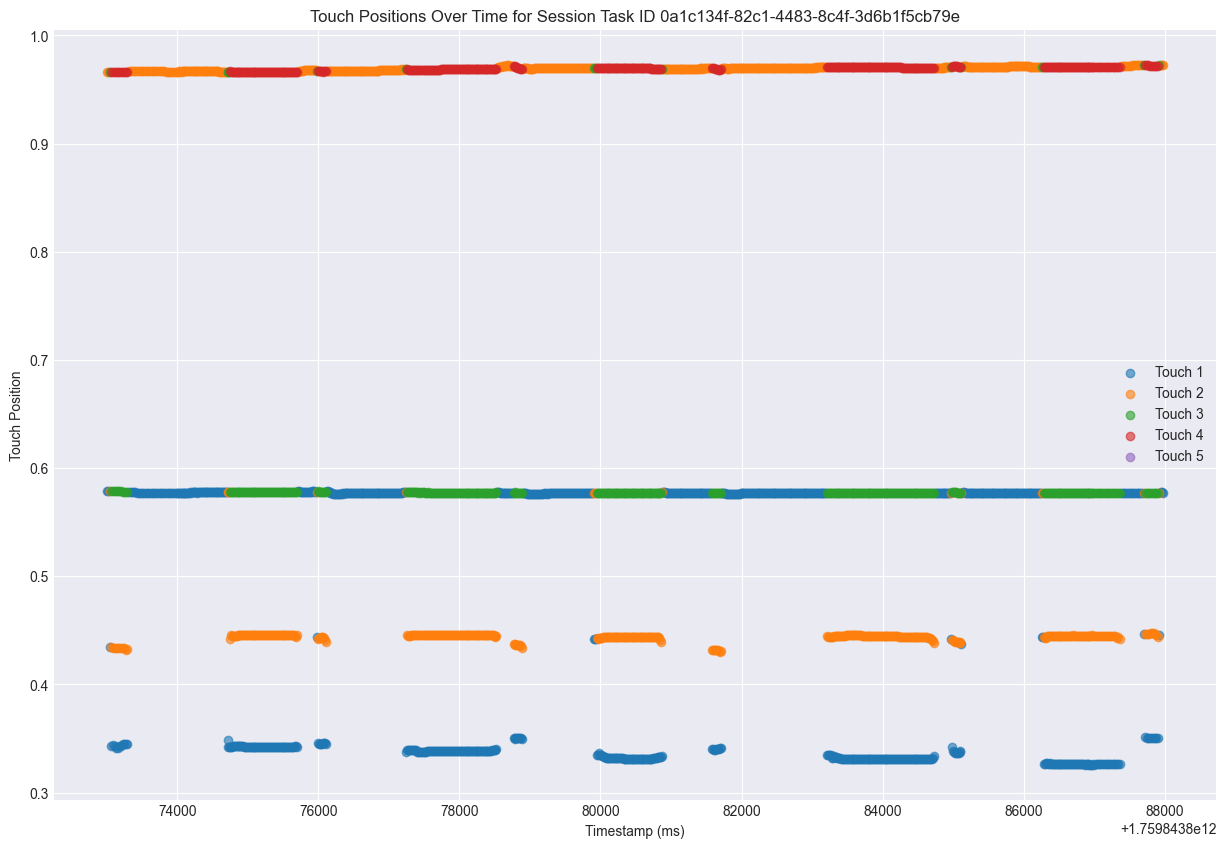

In [15]:
# Show the same graph for the raw data for the first session_task_id
plt.figure(figsize=(15, 10))
first_session_task_id = df_raw["session_task_id"].unique()[0]
session_df = df_raw[df_raw["session_task_id"] == first_session_task_id]
for touch_num in range(1, 6):
    plt.scatter(
        session_df["timestamp_ms"], 
        session_df[f"touch_{touch_num}_position"], 
        label=f"Touch {touch_num}", 
        alpha=0.6
    )
plt.xlabel("Timestamp (ms)")
plt.ylabel("Touch Position")
plt.title(f"Touch Positions Over Time for Session Task ID {first_session_task_id}")
plt.legend()
plt.show()

In [16]:
# Stabilize dataframe, but only the first session_task_id for testing
stabilized_touch_data = process_and_stabilize_touches(df_raw.copy())
non_touch_cols = [c for c in df_raw.columns if not any(c.startswith(f'touch_{i+1}') for i in range(MAX_TOUCHES))]
final_df = df_raw[non_touch_cols].copy()

df_clean = final_df.join(stabilized_touch_data)

print("Stabilization Complete.")

Stabilization Complete.


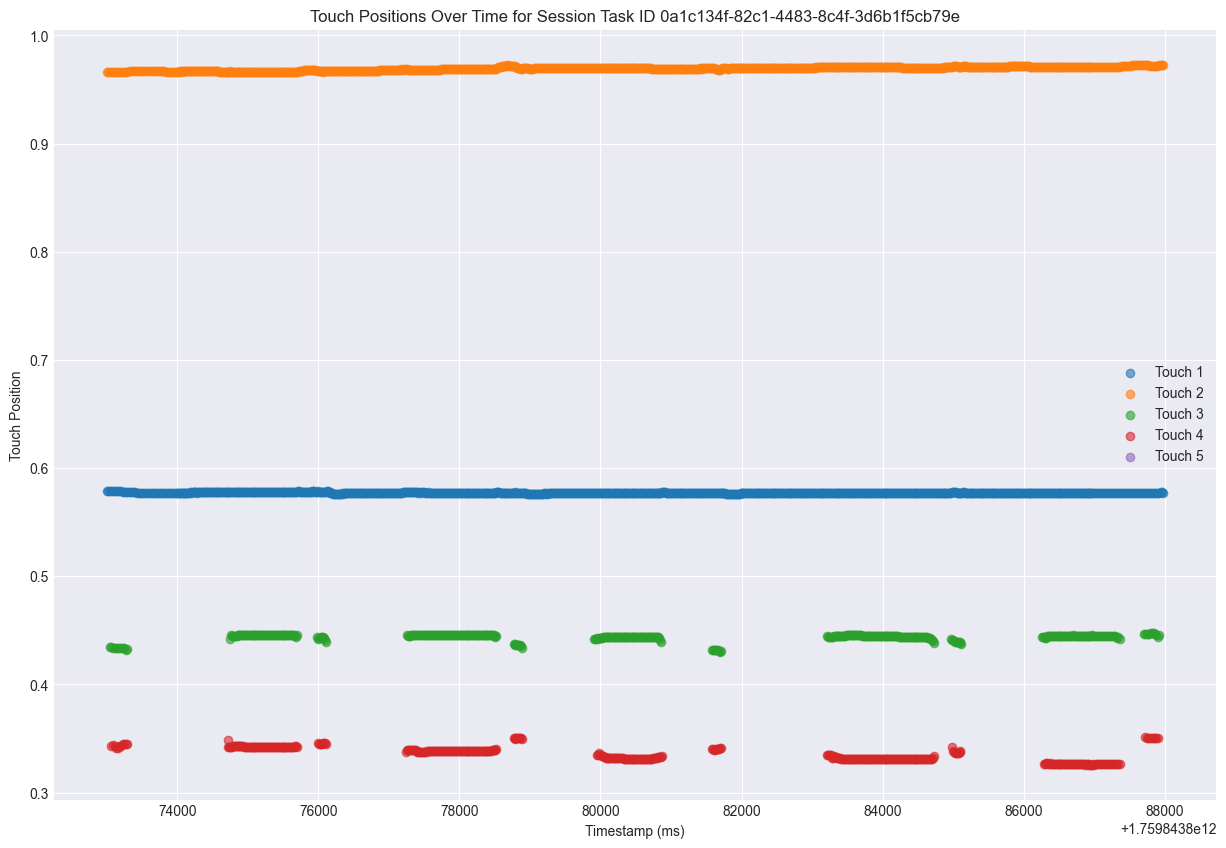

In [17]:
# Show the same graph for the raw data for the first session_task_id
plt.figure(figsize=(15, 10))
first_session_task_id = df_clean["session_task_id"].unique()[0]
session_df = df_clean[df_clean["session_task_id"] == first_session_task_id]
for touch_num in range(1, 6):
    plt.scatter(
        session_df["timestamp_ms"], 
        session_df[f"touch_{touch_num}_position"], 
        label=f"Touch {touch_num}", 
        alpha=0.6
    )
plt.xlabel("Timestamp (ms)")
plt.ylabel("Touch Position")
plt.title(f"Touch Positions Over Time for Session Task ID {first_session_task_id}")
plt.legend()
plt.show()

In [18]:
# Set 0 for null values in position, pressure, channel columns for touches 2 to 5
for touch_num in range(1, 6):
    position_col = f'touch_{touch_num}_position'
    pressure_col = f'touch_{touch_num}_pressure'
    channel_col = f'touch_{touch_num}_channel'
    
    df_clean[position_col] = df_clean[position_col].fillna(0)
    df_clean[pressure_col] = df_clean[pressure_col].fillna(0)
    df_clean[channel_col] = df_clean[channel_col].fillna(0)
df_clean[nan_columns].isna().sum()

touch_1_position    0
touch_1_pressure    0
touch_1_channel     0
touch_2_position    0
touch_2_pressure    0
touch_2_channel     0
touch_3_position    0
touch_3_pressure    0
touch_3_channel     0
touch_4_position    0
touch_4_pressure    0
touch_4_channel     0
touch_5_position    0
touch_5_pressure    0
touch_5_channel     0
dtype: int64

In [19]:
# Print the LABEL_COLUMN counts
print(df_clean[LABEL_COLUMN].value_counts())

parent_gesture
No Gesture                        230485
Pinch Swipe                        12037
Tap and Hold                       11985
Spread Swipe                        9049
Single Swipe                        6072
Two-Finger Opposite Double Tap      3010
Two-Finger Double Tap               3001
Double Tap                          2784
Two-Finger Opposite Tap             1719
Two-Finger Tap                      1646
Single Tap                          1407
Name: count, dtype: int64


In [20]:
# Add new features to the dataframe, for improved modeling
def create_feature_df(df_clean, smoothing_window=3, long_smoothing_window=10, inactive_window=30):
    # Create empty feature dataframe
    feature_df = df_clean.copy()
    additional_features = []

    def add_feature(name, values):
        feature_df[name] = values
        additional_features.append(name)

    # Distances between each finger (including wrapping)
    def short_dist(a, b):
        return np.abs(np.arctan2(np.sin(a - b), np.cos(a - b)))
    
    pressure_col = f'touch_1_pressure'
    rising_edge = ((feature_df[pressure_col] > 0.0) & (feature_df[pressure_col].shift(1) <= 0.0)).astype(int)
    tap_count = rising_edge.rolling(window=long_smoothing_window, min_periods=1).sum()
    for touch_num in range(2, 6):
        position_col = f'touch_{touch_num}_pressure'
        rising_edge = ((feature_df[position_col] > 0.0) & (feature_df[position_col].shift(1) <= 0.0)).astype(int)
        tap_count += rising_edge.rolling(window=long_smoothing_window, min_periods=1).sum()
    add_feature('total_tap_count', tap_count)

    # Smoothed Features
    for touch_num in range(1, 6):
        position_col = f'touch_{touch_num}_position'
        pressure_col = f'touch_{touch_num}_pressure'
        channel_col = f'touch_{touch_num}_channel'

        is_touching = (feature_df[pressure_col] > 0.0).astype(int)
        is_touching_shifted = (feature_df[pressure_col].rolling(window=2, min_periods=1).min() > 0.0).astype(int)

        # A touch is inactive, if it was touching for the whole inactive_window and has not moved more than TOUCH_MOVE_THRESHOLD
        inactive_touch = (is_touching.rolling(window=inactive_window, min_periods=1).sum() >= inactive_window - 1)
        position_diff_during_touch = feature_df[position_col].diff().fillna(0) * is_touching_shifted
        has_moved = (position_diff_during_touch.abs().rolling(window=inactive_window, min_periods=1).max() > TOUCH_MOVE_THRESHOLD)
        is_inactive_touch = inactive_touch & (~has_moved)
        add_feature(f'touch_{touch_num}_is_inactive_touch', is_inactive_touch.astype(int))
        # add_feature(f'touch_{touch_num}_inactive', inactive_touch.astype(int))
        # add_feature(f'touch_{touch_num}_has_moved', has_moved.astype(int))

        # Get the min and max distance to all other fingers
        other_positions = [f'touch_{i}_position' for i in range(1, 6) if i != touch_num]
        if other_positions:
            for other_pos_col in other_positions:
                other_touching = (feature_df[other_pos_col.replace('position', 'pressure')] > 0.0).astype(int)
                both_touching = is_touching * other_touching

                dist_to_other = short_dist(feature_df[position_col], feature_df[other_pos_col]) * both_touching
                add_feature(f'touch_{touch_num}_dist_to_{other_pos_col}', dist_to_other.rolling(window=smoothing_window, min_periods=1).mean())
                add_feature(f'touch_{touch_num}_dist_to_{other_pos_col}_diff', dist_to_other.diff().fillna(0))
                add_feature(f'touch_{touch_num}_dist_to_{other_pos_col}_std', dist_to_other.rolling(window=smoothing_window, min_periods=1).std().fillna(0))
        
        # calculate the tap count within the long window
        rising_edge = ((feature_df[pressure_col] > 0.0) & (feature_df[pressure_col].shift(1) <= 0.0)).astype(int)
        tap_count = rising_edge.rolling(window=long_smoothing_window, min_periods=1).sum()
        add_feature(f'touch_{touch_num}_tap_count', tap_count)

        add_feature(f'{position_col}_mean', feature_df[position_col].rolling(window=smoothing_window, min_periods=1).mean())
        add_feature(f'{pressure_col}_mean', feature_df[pressure_col].rolling(window=smoothing_window, min_periods=1).mean())
        # add_feature(f'{channel_col}_mean', feature_df[channel_col].rolling(window=smoothing_window, min_periods=1).mean())
        
        # add_feature(f'{position_col}_diff', feature_df[position_col].diff().fillna(0))
        # add_feature(f'{pressure_col}_diff', feature_df[pressure_col].diff().fillna(0))
        # add_feature(f'{channel_col}_diff', feature_df[channel_col].diff().fillna(0))
        # Only calculate diff for position and pressure, that happen within touches, so while is_touching
        add_feature(f'{position_col}_diff', feature_df[position_col].diff().fillna(0) * is_touching_shifted)
        add_feature(f'{pressure_col}_diff', feature_df[pressure_col].diff().fillna(0) * is_touching_shifted)
        # add_feature(f'{channel_col}_diff', feature_df[channel_col].diff().fillna(0) * is_touching_shifted)
        
        add_feature(f'{position_col}_rollstd', feature_df[position_col].rolling(window=smoothing_window, min_periods=1).std().fillna(0))
        add_feature(f'{pressure_col}_rollstd', feature_df[pressure_col].rolling(window=smoothing_window, min_periods=1).std().fillna(0))
        # add_feature(f'{channel_col}_rollstd', feature_df[channel_col].rolling(window=smoothing_window, min_periods=1).std().fillna(0))
        
        p_diff = feature_df[f'{position_col}_diff']
        add_feature(f'{position_col}_accel', p_diff.diff().fillna(0))

    return feature_df, additional_features

In [21]:
def get_column_names(feature_columns):
    return feature_columns
    # return SENSOR_COLUMNS
    # return SENSOR_COLUMNS + feature_columns

In [22]:
# df_clean = augment_data_all_permutations(df_clean, limit=10)

In [23]:
df, additional_columns = create_feature_df(df_clean)
feature_columns = get_column_names(additional_columns)

df = df.sort_values(
    by=["participant_id", "session_task_id", TIMESTAMP_COLUMN]
).reset_index(drop=True)

gesture_block = 0
prev_pid = None
prev_sid = None
prev_is_gesture = None
prev_label = None
blocks = []
prev_group_id = None

for i, row in df.iterrows():
    pid = row["participant_id"]
    sid = row["session_task_id"]
    is_g = row["is_gesture"]
    lab = row[LABEL_COLUMN]
    group_id = row["group_id"]

    # New block when:
    # - participant or session changes
    # - or gesture/background state changes
    # - or gesture label changes
    if (
        pid != prev_pid or
        sid != prev_sid or
        is_g != prev_is_gesture or
        lab != prev_label or
        group_id != prev_group_id
    ):
        gesture_block += 1

    blocks.append(gesture_block)

    prev_pid = pid
    prev_sid = sid
    prev_is_gesture = is_g
    prev_label = lab
    prev_group_id = group_id

df["gesture_block"] = blocks

In [24]:
df.head()

,id,session_task_id,session_task_row_index,timestamp,timestamp_ms,button_pressed,motor_angle,gesture,parent_gesture,participant_id,is_gesture,group_id,estimated_timestamp,touch_1_position,touch_1_pressure,touch_1_channel,touch_2_position,touch_2_pressure,touch_2_channel,touch_3_position,touch_3_pressure,touch_3_channel,touch_4_position,touch_4_pressure,touch_4_channel,touch_5_position,touch_5_pressure,touch_5_channel,active_ids,total_tap_count,touch_1_is_inactive_touch,touch_1_dist_to_touch_2_position,touch_1_dist_to_touch_2_position_diff,touch_1_dist_to_touch_2_position_std,touch_1_dist_to_touch_3_position,touch_1_dist_to_touch_3_position_diff,touch_1_dist_to_touch_3_position_std,touch_1_dist_to_touch_4_position,touch_1_dist_to_touch_4_position_diff,touch_1_dist_to_touch_4_position_std,touch_1_dist_to_touch_5_position,touch_1_dist_to_touch_5_position_diff,touch_1_dist_to_touch_5_position_std,touch_1_tap_count,touch_1_position_mean,touch_1_pressure_mean,touch_1_position_diff,touch_1_pressure_diff,touch_1_position_rollstd,touch_1_pressure_rollstd,touch_1_position_accel,touch_2_is_inactive_touch,touch_2_dist_to_touch_1_position,touch_2_dist_to_touch_1_position_diff,touch_2_dist_to_touch_1_position_std,touch_2_dist_to_touch_3_position,touch_2_dist_to_touch_3_position_diff,touch_2_dist_to_touch_3_position_std,touch_2_dist_to_touch_4_position,touch_2_dist_to_touch_4_position_diff,touch_2_dist_to_touch_4_position_std,touch_2_dist_to_touch_5_position,touch_2_dist_to_touch_5_position_diff,touch_2_dist_to_touch_5_position_std,touch_2_tap_count,touch_2_position_mean,touch_2_pressure_mean,touch_2_position_diff,touch_2_pressure_diff,touch_2_position_rollstd,touch_2_pressure_rollstd,touch_2_position_accel,touch_3_is_inactive_touch,touch_3_dist_to_touch_1_position,touch_3_dist_to_touch_1_position_diff,touch_3_dist_to_touch_1_position_std,touch_3_dist_to_touch_2_position,touch_3_dist_to_touch_2_position_diff,touch_3_dist_to_touch_2_position_std,touch_3_dist_to_touch_4_position,touch_3_dist_to_touch_4_position_diff,touch_3_dist_to_touch_4_position_std,touch_3_dist_to_touch_5_position,touch_3_dist_to_touch_5_position_diff,touch_3_dist_to_touch_5_position_std,touch_3_tap_count,touch_3_position_mean,touch_3_pressure_mean,touch_3_position_diff,touch_3_pressure_diff,touch_3_position_rollstd,touch_3_pressure_rollstd,touch_3_position_accel,touch_4_is_inactive_touch,touch_4_dist_to_touch_1_position,touch_4_dist_to_touch_1_position_diff,touch_4_dist_to_touch_1_position_std,touch_4_dist_to_touch_2_position,touch_4_dist_to_touch_2_position_diff,touch_4_dist_to_touch_2_position_std,touch_4_dist_to_touch_3_position,touch_4_dist_to_touch_3_position_diff,touch_4_dist_to_touch_3_position_std,touch_4_dist_to_touch_5_position,touch_4_dist_to_touch_5_position_diff,touch_4_dist_to_touch_5_position_std,touch_4_tap_count,touch_4_position_mean,touch_4_pressure_mean,touch_4_position_diff,touch_4_pressure_diff,touch_4_position_rollstd,touch_4_pressure_rollstd,touch_4_position_accel,touch_5_is_inactive_touch,touch_5_dist_to_touch_1_position,touch_5_dist_to_touch_1_position_diff,touch_5_dist_to_touch_1_position_std,touch_5_dist_to_touch_2_position,touch_5_dist_to_touch_2_position_diff,touch_5_dist_to_touch_2_position_std,touch_5_dist_to_touch_3_position,touch_5_dist_to_touch_3_position_diff,touch_5_dist_to_touch_3_position_std,touch_5_dist_to_touch_4_position,touch_5_dist_to_touch_4_position_diff,touch_5_dist_to_touch_4_position_std,touch_5_tap_count,touch_5_position_mean,touch_5_pressure_mean,touch_5_position_diff,touch_5_pressure_diff,touch_5_position_rollstd,touch_5_pressure_rollstd,touch_5_position_accel,gesture_block
0,7ae236df-3b8a-46fe-be4b-fcabf2850ad1,0a1c134f-82c1-4483-8c4f-3d6b1f5cb79e,639,2025-10-07 13:31:13,1759843873000,0,0.997409,Two-Finger Tap (4 Finger),Two-Finger Tap,5d52daf3-c962-4db6-a8f8-298a0bb01733,1,03f74f16-3fea-4c43-9979-64c4636df12a,2025-10-07 13:31:13.000000000,0.578513,0.377551,0.400000,0.966209,0.572171,0.500000,0.000000,0.000000,0.0,0.000

In [25]:
# Print unique "gesture" column counts
print(df["gesture"].value_counts())

gesture
Tap and Hold (3 Finger)                      22873
Pinch Swipe (Rechts)                         14960
Tap and Hold (2 Finger)                      14352
Two-Finger Tap (3 Finger)                    13072
Lay On (2 Fingers)                           12997
Two-Finger Double Tap (4 Finger)             12911
Pinch Swipe (Links)                          12417
Knob Turn (3 Fingers)                        12172
Knob Turn (All Fingers)                      11944
Lay On (3 Fingers)                           11869
Double Tap (4 Finger)                        10872
Spread Swipe (Rechts)                        10249
Two-Finger Double Tap (3 Finger)             10028
Two-Finger Opposite Double Tap (4 Finger)     9715
Single Swipe (All Air)                        9707
Spread Swipe (Links)                          9332
Two-Finger Opposite Tap (4 Finger)            9185
Single Swipe (3 Finger)                       9109
Two-Finger Tap (4 Finger)                     8999
Two-Finger Opposite Tap

In [29]:
gesture_blocks = (
    df
    .groupby(["participant_id", "session_task_id", "group_id", "gesture_block"])
)
print(f"Total gesture blocks (excluding 'No Gesture'): {len(gesture_blocks)}")

Total gesture blocks (excluding 'No Gesture'): 3241


In [30]:
sequences = []   # list of arrays, each (T_i, D)
labels = []      # list of strings or ints
meta = []

for (pid, sid, group_id, gb), gdf in gesture_blocks:
    # Extract feature matrix for this gesture
    X_seq = gdf[feature_columns].to_numpy(dtype="float32")  # shape (T_i, D)
    if len(X_seq) == 0:
        continue

    sequences.append(X_seq)
    labels.append(gdf[LABEL_COLUMN].iloc[0])  # all rows in block share the same label
    meta.append({
        "group_id": group_id,
        "participant_id": pid,
        "session_task_id": sid,
        "gesture_block": gb,
        "num_samples": len(X_seq),
    })

In [31]:
# Print the number of sequences and unique labels
print(f"Extracted {len(sequences)} sequences with {len(set(labels))} unique labels.")
# Print the unique labels and their counts
label_counts = pd.Series(labels).value_counts()
print("Label counts:")
for label, count in label_counts.items():
    print(f"  {label}: {count}")

Extracted 3241 sequences with 11 unique labels.
Label counts:
  No Gesture: 2243
  Two-Finger Tap: 109
  Pinch Swipe: 103
  Double Tap: 101
  Two-Finger Opposite Tap: 101
  Single Tap: 100
  Two-Finger Opposite Double Tap: 98
  Single Swipe: 97
  Two-Finger Double Tap: 97
  Tap and Hold: 96
  Spread Swipe: 96


In [32]:
feature_columns

['total_tap_count',
 'touch_1_is_inactive_touch',
 'touch_1_dist_to_touch_2_position',
 'touch_1_dist_to_touch_2_position_diff',
 'touch_1_dist_to_touch_2_position_std',
 'touch_1_dist_to_touch_3_position',
 'touch_1_dist_to_touch_3_position_diff',
 'touch_1_dist_to_touch_3_position_std',
 'touch_1_dist_to_touch_4_position',
 'touch_1_dist_to_touch_4_position_diff',
 'touch_1_dist_to_touch_4_position_std',
 'touch_1_dist_to_touch_5_position',
 'touch_1_dist_to_touch_5_position_diff',
 'touch_1_dist_to_touch_5_position_std',
 'touch_1_tap_count',
 'touch_1_position_mean',
 'touch_1_pressure_mean',
 'touch_1_position_diff',
 'touch_1_pressure_diff',
 'touch_1_position_rollstd',
 'touch_1_pressure_rollstd',
 'touch_1_position_accel',
 'touch_2_is_inactive_touch',
 'touch_2_dist_to_touch_1_position',
 'touch_2_dist_to_touch_1_position_diff',
 'touch_2_dist_to_touch_1_position_std',
 'touch_2_dist_to_touch_3_position',
 'touch_2_dist_to_touch_3_position_diff',
 'touch_2_dist_to_touch_3_posi

In [33]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

le = LabelEncoder()
y_int = le.fit_transform(labels)           # shape (N,)
num_classes = len(le.classes_)
y = to_categorical(y_int, num_classes)     # shape (N, num_classes)


In [96]:
# Store label encoder
import pickle
with open("class_gesture_lstm_aio_label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

In [35]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = max(seq.shape[0] for seq in sequences)  # e.g. 400
D = sequences[0].shape[1]
print(max_len)

X_padded = pad_sequences(
    sequences,
    maxlen=max_len,
    dtype="float32",
    padding="pre",
    truncating="pre",
    value=0.0      # padding value
)  # shape: (N, max_len, D)
X = X_padded


3497


In [36]:
unique_participants = df['participant_id'].unique()
print(f"Unique participants: {len(unique_participants)}")

amount_of_participants = len(unique_participants)
amount_of_val_participants = max(1, int(0.2 * amount_of_participants))
amount_of_test_participants = max(1, int(0.2 * amount_of_participants))

np.random.seed(42)
val_participants = np.random.choice(unique_participants, size=amount_of_val_participants, replace=False)
remaining_participants = [p for p in unique_participants if p not in val_participants]
test_participants = np.random.choice(remaining_participants, size=amount_of_test_participants, replace=False)
train_participants = [p for p in remaining_participants if p not in test_participants]

print(f"Train participants: {train_participants}")
print(f"Validation participants: {val_participants}")
print(f"Test participants: {test_participants}")

Unique participants: 8
Train participants: ['5d52daf3-c962-4db6-a8f8-298a0bb01733', '696b4743-9d39-4fb1-8271-90e7d48652af', '6a1b56e6-47ce-43cb-96cb-713d055d8f6d', '707c3867-fe15-4b05-bf7b-fc5f3b501fb1', '754f0f37-a3b5-4f3d-aaf4-7d4e1a8cafd0', 'fdd02af8-c764-43ba-8247-c612f85568b4']
Validation participants: ['6331fbd1-76bb-48d6-92a2-80a55a70d134']
Test participants: ['d3b39f0f-b799-4d69-b7a3-a663e5c7438f']


In [37]:
# Split participants into train, val, test sets
train_indices = df['participant_id'].isin(train_participants)
val_indices = df['participant_id'].isin(val_participants)
test_indices = df['participant_id'].isin(test_participants)

# Map each sequence back to its participant_id
sequence_participants = []
gesture_block_keys = list(gesture_blocks.groups.keys())
for (pid, sid, grpid, gb) in gesture_block_keys:
    sequence_participants.append(pid)
sequence_participants = np.array(sequence_participants)
# Now create boolean masks for sequences
train_seq_indices = np.isin(sequence_participants, train_participants)
val_seq_indices = np.isin(sequence_participants, val_participants)
test_seq_indices = np.isin(sequence_participants, test_participants)

X_train, y_train = X[train_seq_indices], y[train_seq_indices]
X_val, y_val = X[val_seq_indices], y[val_seq_indices]
X_test, y_test = X[test_seq_indices], y[test_seq_indices]
print(f"Train set: {X_train.shape}, {y_train.shape}")
print(f"Validation set: {X_val.shape}, {y_val.shape}")
print(f"Test set: {X_test.shape}, {y_test.shape}")

Train set: (2635, 3497, 106), (2635, 11)
Validation set: (304, 3497, 106), (304, 11)
Test set: (302, 3497, 106), (302, 11)


In [38]:
# # describe the running_tap_count_long in the X_train data with min max and mean
# running_tap_count_long_index = feature_columns.index('touch_1_tap_counts')
# train_running_tap_counts = X_train[:, :, running_tap_count_long_index]
# print(f"running_tap_count_long in training set: min={train_running_tap_counts.min()}, max={train_running_tap_counts.max()}, mean={train_running_tap_counts.mean()}")

In [39]:
# # # Draw a graph of the first X_train sequence with the double tap label
# first_double_tap_index = np.argmax(y_train[:, le.transform(['Double Tap'])]) + 1
# plt.figure(figsize=(15, 10))
# for touch_num in range(1, 6):
#     # finger_window = X_train[first_double_tap_index, :, feature_columns.index(f'touch_{touch_num}_position_mean')]
#     # plt.scatter(
#     #     range(len(finger_window)),
#     #     finger_window,
#     #     label=f"Touch {touch_num} Position"
#     # )
#     finger_window = X_train[first_double_tap_index, :, feature_columns.index(f'touch_{touch_num}_is_inactive_touch')]
#     plt.scatter(
#         range(len(finger_window)),
#         finger_window + (touch_num - 1) * 0.05 + 2,  # offset for visibility
#         label=f"Touch {touch_num} Inactive"
#     )
#     # finger_window = X_train[first_double_tap_index, :, feature_columns.index(f'touch_{touch_num}_inactive')]
#     # plt.scatter(
#     #     range(len(finger_window)),
#     #     finger_window + (touch_num - 1) * 0.05 + 3,  # offset for visibility
#     #     label=f"Touch {touch_num} Inactive"
#     # )
#     # finger_window = X_train[first_double_tap_index, :, feature_columns.index(f'touch_{touch_num}_has_moved')]
#     # plt.scatter(
#     #     range(len(finger_window)),
#     #     finger_window + (touch_num - 1) * 0.05 + 4,  # offset for visibility
#     #     label=f"Touch {touch_num} Moving"
#     # )
# # finger_window = X_train[first_double_tap_index, :, feature_columns.index(f'total_tap_count')]
# # plt.scatter(
# #     range(len(finger_window)),
# #     finger_window,
# #     label=f"Touch Touch Count"
# # )
# plt.xlabel("Time Step")
# plt.ylabel("Touch Position")
# plt.title("Touch Positions Over Time for First 'Double Tap' in Training Set")
# plt.xlim(375, 425)
# plt.legend()
# plt.show()

In [40]:
# # # Draw a graph of the first X_train sequence with the double tap label
# first_double_tap_index = np.argmax(y_train[:, le.transform(['Two-Finger Opposite Double Tap'])]) + 1
# plt.figure(figsize=(15, 10))
# for touch_num in range(1, 6):
#     finger_window = X_train[first_double_tap_index, :, feature_columns.index(f'touch_{touch_num}_position_mean')]
#     plt.scatter(
#         range(len(finger_window)),
#         finger_window,
#         label=f"Touch {touch_num} Position"
#     )
#     finger_window = X_train[first_double_tap_index, :, feature_columns.index(f'touch_{touch_num}_is_inactive_touch')]
#     plt.scatter(
#         range(len(finger_window)),
#         finger_window + (touch_num - 1) * 0.05 + 2,  # offset for visibility
#         label=f"Touch {touch_num} Touch Count"
#     )
#     # finger_window = X_train[first_double_tap_index, :, feature_columns.index(f'touch_{touch_num}_debug2')]
#     # plt.scatter(
#     #     range(len(finger_window)),
#     #     finger_window + (touch_num - 1) * 0.05 + 4,  # offset for visibility
#     #     label=f"Touch {touch_num} Touch Count"
#     # )
#     # finger_window = X_train[first_double_tap_index, :, feature_columns.index(f'touch_{touch_num}_debug3')]
#     # plt.scatter(
#     #     range(len(finger_window)),
#     #     finger_window + (touch_num - 1) * 0.05 + 6,  # offset for visibility
#     #     label=f"Touch {touch_num} Touch Count"
#     # )
# # finger_window = X_train[first_double_tap_index, :, feature_columns.index(f'total_tap_count')]
# # plt.scatter(
# #     range(len(finger_window)),
# #     finger_window,
# #     label=f"Touch Touch Count"
# # )
# plt.xlabel("Time Step")
# plt.ylabel("Touch Position")
# plt.title("Touch Positions Over Time for First 'Double Tap' in Training Set")
# plt.xlim(375, 425)
# plt.legend()
# plt.show()

In [41]:
# Per label, print the amount of samples in each split in one row
train_counts = pd.Series(np.argmax(y_train, axis=1)).value_counts().sort_index()
val_counts = pd.Series(np.argmax(y_val, axis=1)).value_counts().sort_index()
test_counts = pd.Series(np.argmax(y_test, axis=1)).value_counts().sort_index()
print("Label counts per split:")
for label_idx in range(num_classes):
    train_count = train_counts.get(label_idx, 0)
    val_count = val_counts.get(label_idx, 0)
    test_count = test_counts.get(label_idx, 0)
    label_name = le.classes_[label_idx]
    print(f"  {label_name}: Train={train_count}, Val={val_count}, Test={test_count}")

Label counts per split:
  Double Tap: Train=76, Val=12, Test=13
  No Gesture: Train=1893, Val=175, Test=175
  Pinch Swipe: Train=78, Val=13, Test=12
  Single Swipe: Train=72, Val=12, Test=13
  Single Tap: Train=76, Val=12, Test=12
  Spread Swipe: Train=70, Val=12, Test=14
  Tap and Hold: Train=72, Val=11, Test=13
  Two-Finger Double Tap: Train=70, Val=15, Test=12
  Two-Finger Opposite Double Tap: Train=72, Val=14, Test=12
  Two-Finger Opposite Tap: Train=75, Val=12, Test=14
  Two-Finger Tap: Train=81, Val=16, Test=12


In [98]:
from sklearn.utils.class_weight import compute_class_weight

y_train_labels = np.argmax(y_train, axis=1)

classes = np.unique(y_train_labels)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_labels
)

class_weights = dict(zip(classes, class_weights_array))
print(class_weights)

{np.int64(0): np.float64(3.151913875598086), np.int64(1): np.float64(0.12654276521154492), np.int64(2): np.float64(3.071095571095571), np.int64(3): np.float64(3.327020202020202), np.int64(4): np.float64(3.151913875598086), np.int64(5): np.float64(3.4220779220779223), np.int64(6): np.float64(3.327020202020202), np.int64(7): np.float64(3.4220779220779223), np.int64(8): np.float64(3.327020202020202), np.int64(9): np.float64(3.193939393939394), np.int64(10): np.float64(2.957351290684624)}


In [105]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Masking, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

max_len = X_train.shape[1]
D = X_train.shape[2]
num_classes = y_train.shape[1]

model = Sequential()

# 1) Masking: ignore padded timesteps (value=0.0 from preprocessing)
model.add(Masking(mask_value=0.0, input_shape=(max_len, D)))
model.add(LSTM(128, return_sequences=True))
model.add(LSTM(64))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dense(num_classes, activation="softmax"))
optimizer = Adam(learning_rate=5e-4)
model.compile(
    loss="categorical_crossentropy",
    optimizer=optimizer,
    metrics=["accuracy"]
)
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_3 (Masking)             │ (None, 3497, 106)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 3497, 128)      │       120,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 11)             │           715 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 174,603 (682.04 KB)

 Trainable params: 174,603 (682.04 KB)

 Non-trainable params: 0 (0.00 B)

In [106]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

batch_size = 16     # optimization knob: [16, 32, 64]
epochs = 100        # upper limit; early stopping will cut it earlier

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True,
    callbacks=callbacks,
    class_weight=class_weights,
)

Epoch 1/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 425s 3s/step - accuracy: 0.4228 - loss: 1.9630 - val_accuracy: 0.4079 - val_loss: 2.0759
Epoch 2/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 409s 2s/step - accuracy: 0.6011 - loss: 1.3704 - val_accuracy: 0.3947 - val_loss: 2.0307
Epoch 3/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 409s 2s/step - accuracy: 0.6338 - loss: 1.1281 - val_accuracy: 0.4737 - val_loss: 1.7875
Epoch 4/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 397s 2s/step - accuracy: 0.6577 - loss: 0.8996 - val_accuracy: 0.4638 - val_loss: 1.5810
Epoch 5/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 406s 2s/step - accuracy: 0.6702 - loss: 0.8561 - val_accuracy: 0.4013 - val_loss: 1.8346
Epoch 6/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 405s 2s/step - accuracy: 0.6520 - loss: 0.8923 - val_accuracy: 0.4967 - val_loss: 1.4619
Epoch 7/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 407s 2s/step - accuracy: 0.6922 - loss: 0.6523 - val_accuracy: 0.5099 - val_loss: 1.3067
Epoch 8/100
165/165 ━━━━━━━━━━━━━━━━━━━━ 400s 2s/step - accuracy: 0.6972 - loss: 0.6192 - 

10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 475ms/step
                                precision    recall  f1-score   support

                    Double Tap       0.92      0.85      0.88        13
                    No Gesture       0.99      0.94      0.97       175
                   Pinch Swipe       0.92      1.00      0.96        12
                  Single Swipe       0.62      0.77      0.69        13
                    Single Tap       0.86      1.00      0.92        12
                  Spread Swipe       0.88      1.00      0.93        14
                  Tap and Hold       1.00      0.92      0.96        13
         Two-Finger Double Tap       0.71      1.00      0.83        12
Two-Finger Opposite Double Tap       1.00      0.75      0.86        12
       Two-Finger Opposite Tap       1.00      0.93      0.96        14
                Two-Finger Tap       0.86      1.00      0.92        12

                      accuracy                           0.93       302
                     

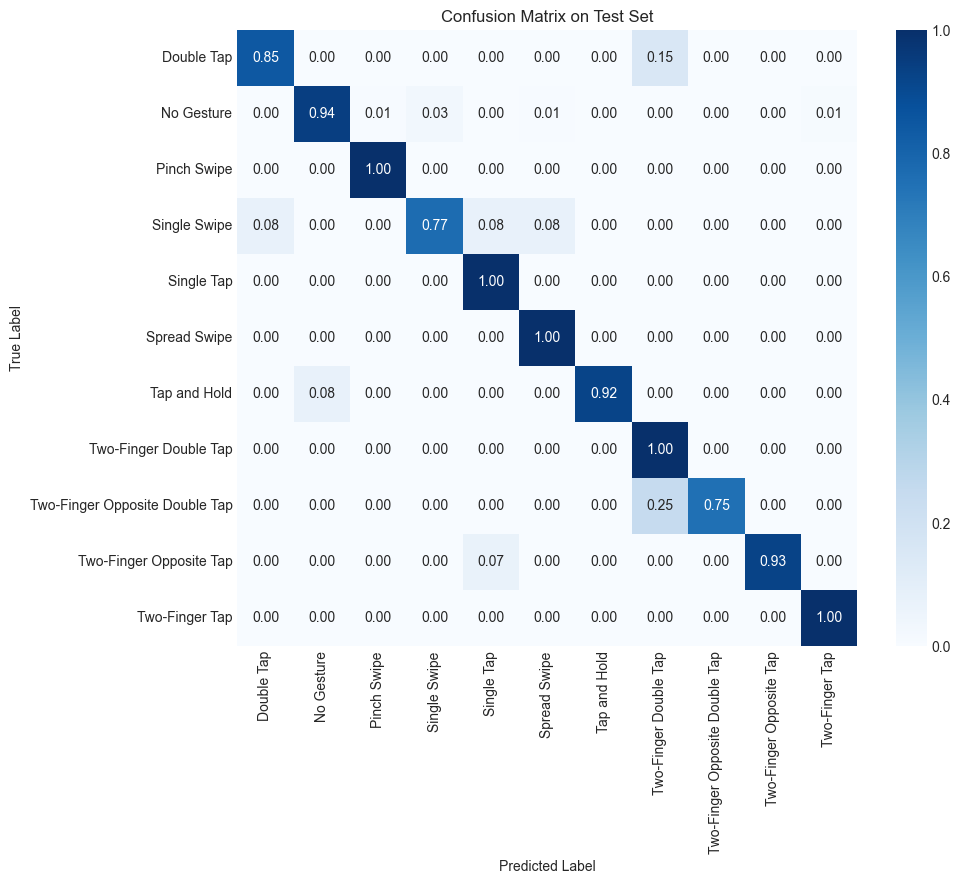

In [107]:
# Draw heatmap of confusion matrix for test set
from sklearn.metrics import confusion_matrix, classification_report

y_test_pred_probs = model.predict(X_test)
y_test_pred = np.argmax(y_test_pred_probs, axis=1)
y_test_true = np.argmax(y_test, axis=1)

used_labels = np.unique(np.concatenate([y_test_true, y_test_pred]))
used_label_names = le.inverse_transform(used_labels)
print(
    classification_report(
        y_test_true, y_test_pred, 
        labels=used_labels, target_names=used_label_names
    )
)

cm = confusion_matrix(y_test_true, y_test_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix on Test Set')
plt.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 456ms/step


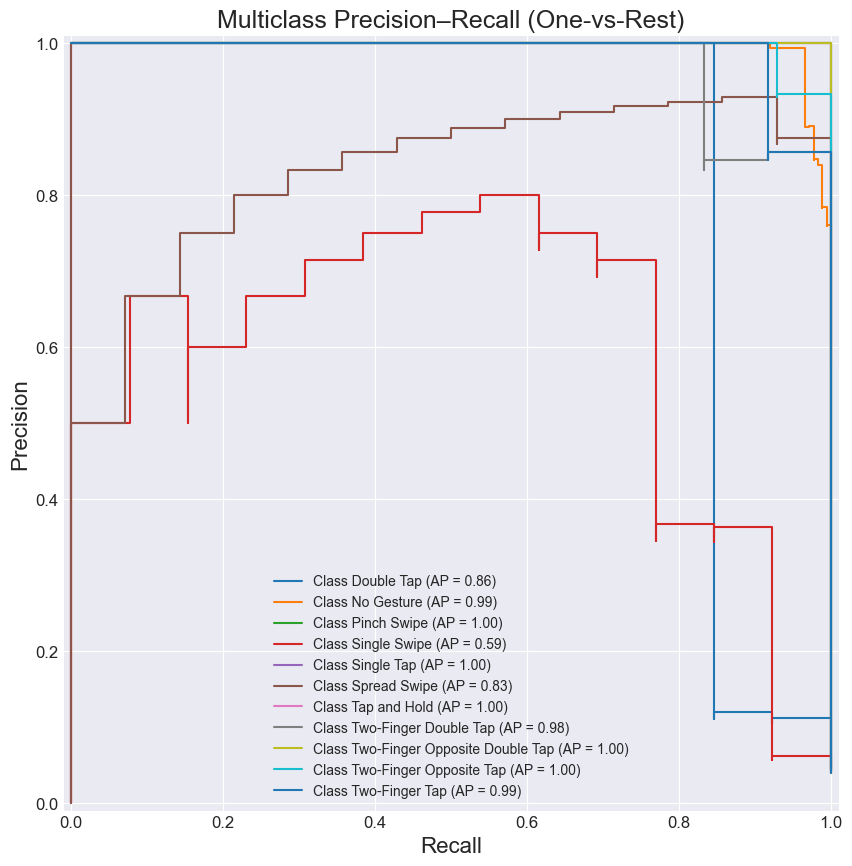

In [108]:
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.preprocessing import label_binarize

# predict probabilities
y_test_proba = model.predict(X_test)

# binarize labels
y_test_bin = label_binarize(y_test, classes=le.classes_)

fig, ax = plt.subplots(figsize=(10, 12))

for i, cls in enumerate(range(num_classes)):
    cls_label = le.inverse_transform([cls])[0]
    PrecisionRecallDisplay.from_predictions(
        y_test_bin[:, i],
        y_test_proba[:, i],
        name=f"Class {cls_label}",
        ax=ax
    )
ax.set_xlabel("Recall", fontsize=16)
ax.set_ylabel("Precision", fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.legend(fontsize=12)
ax.set_title("Multiclass Precision–Recall (One-vs-Rest)", fontsize=18)
ax.legend()
plt.show()

In [109]:
# store model on disk
MODEL_PATH = "best_class_gesture_lstm_aio_padded_recognition_model.h5"
model.save(MODEL_PATH)

## Test with Szenarios

In [110]:
# Get all sensor data from markers within the 'Szenarien' parent task, though the markers there are not "start" and "end", but multiple different in the pattern "marker:xxx:start" and "marker:xxx:end"
szenarien_query = """
WITH start_end_indices AS (
    SELECT
        s.session_task_id,
        s.sensor_data_index AS start_index,
        MIN(e.sensor_data_index) AS next_end_index
    FROM preciseMarker s
    JOIN preciseMarker e 
        ON e.session_task_id = s.session_task_id
       AND e.sensor_data_index > s.sensor_data_index
    WHERE s.marker_type = 'start'
      AND e.marker_type = 'end'
    GROUP BY s.session_task_id, s.sensor_data_index
),
start_marker_timestamps AS (
    SELECT
        sensorData.session_task_id,
        session_task_row_index,
        timestamp AS group_id
    FROM sensorData
    JOIN preciseMarker
        ON sensorData.session_task_id = preciseMarker.session_task_id
       AND session_task_row_index = preciseMarker.sensor_data_index
    WHERE preciseMarker.marker_type = 'start'
),
marker_indices AS (
    SELECT
        s.session_task_id,
        s.sensor_data_index AS start_index,
        s.marker_type,
        MIN(e.sensor_data_index) AS end_index
    FROM preciseMarker s
    JOIN preciseMarker e 
        ON e.session_task_id = s.session_task_id
       AND e.sensor_data_index > s.sensor_data_index
    JOIN sessionTask st
      ON s.session_task_id = st.id
    JOIN recordingTask rt
      ON st.recording_task_id = rt.id
    JOIN recordingTask rtParent
      ON rt.parent_id = rtParent.id
    WHERE rtParent.title = 'Szenarien'
      AND s.marker_type LIKE 'marker:%:start'
      AND e.marker_type LIKE 'marker:%:end'
    GROUP BY s.session_task_id, s.sensor_data_index
)
SELECT
    sd.id,
    sd.session_task_id,
    sd.session_task_row_index,
    sd.timestamp,
    sd.button_pressed,
    sd.motor_angle,
    sd.touch_1_position,
    sd.touch_1_pressure,
    sd.touch_1_channel,
    sd.touch_2_position,
    sd.touch_2_pressure,
    sd.touch_2_channel,
    sd.touch_3_position,
    sd.touch_3_pressure,
    sd.touch_3_channel,
    sd.touch_4_position,
    sd.touch_4_pressure,
    sd.touch_4_channel,
    sd.touch_5_position,
    sd.touch_5_pressure,
    sd.touch_5_channel,
    rt.title AS gesture,
    rtParent.title AS parent_gesture,
    s.participant_id,
    CASE WHEN mi.marker_type is null or SUBSTR(mi.marker_type, 8, LENGTH(mi.marker_type) - 13) = 'No Gesture' THEN 0 ELSE 1 END AS is_gesture,
    -- Get marker type without the 'marker:' prefix and ':start' suffix
    SUBSTR(mi.marker_type, 8, LENGTH(mi.marker_type) - 13) AS marker_label,
    (smt.group_id || '-' || mi.marker_type || '-' || mi.start_index) AS group_id
FROM sensorData sd
JOIN start_end_indices sei
    ON sd.session_task_id = sei.session_task_id
    AND sd.session_task_row_index BETWEEN sei.start_index AND sei.next_end_index
JOIN start_marker_timestamps smt
    ON smt.session_task_id = sei.session_task_id
    AND smt.session_task_row_index = sei.start_index
LEFT JOIN marker_indices mi
  ON sd.session_task_id = mi.session_task_id
 AND sd.session_task_row_index BETWEEN mi.start_index AND mi.end_index
LEFT JOIN sessionTask st
  ON sd.session_task_id = st.id
LEFT JOIN session s
    ON st.session_id = s.id
LEFT JOIN recordingTask rt
    ON st.recording_task_id = rt.id
LEFT JOIN recordingTask rtParent
    ON rt.parent_id = rtParent.id
WHERE rtParent.title = 'Szenarien'
ORDER BY sd.session_task_id, sd.session_task_row_index;
"""
with sqlite3.connect(DB_PATH) as conn:
    szenarien_df_raw = pd.read_sql_query(szenarien_query, conn)
szenarien_df_raw.head()

,id,session_task_id,session_task_row_index,timestamp,button_pressed,motor_angle,touch_1_position,touch_1_pressure,touch_1_channel,touch_2_position,touch_2_pressure,touch_2_channel,touch_3_position,touch_3_pressure,touch_3_channel,touch_4_position,touch_4_pressure,touch_4_channel,touch_5_position,touch_5_pressure,touch_5_channel,gesture,parent_gesture,participant_id,is_gesture,marker_label,group_id
0,1668ffd2-1939-41a9-97dc-906cc8041084,002f4422-1f7b-4859-8f03-467e1f752000,325,2025-10-07 14:11:50,0,176.685837,0.410596,2048.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dateien kopieren,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,None,None
1,7cc63c58-ff05-4c43-ace6-ce2038a4da66,002f4422-1f7b-4859-8f03-467e1f752000,326,2025-10-07 14:11:50,0,176.686600,0.409281,2062.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dateien kopieren,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,None,None
2,4e727221-45fa-432a-b972-5ee640c533a7,002f4422-1f7b-4859-8f03-467e1f752000,327,2025-10-07 14:11:50,0,176.686218,0.407342,2065.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dateien kopieren,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,None,None
3,cd025956-225d-45c0-9380-76c934284585,002f4422-1f7b-4859-8f03-467e1f752000,328,2025-10-07 14:11:50,0,176.686218,0.406749,2072.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dateien kopieren,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,None,None
4,2337a772-c876-4cd2-a5e7-ac42f6dad3ab,002f4422-1f7b-4859-8f03-467e1f752000,329,2025-10-07 14:11:50,0,176.686600,0.405720,2073.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dateien kopieren,Szenarien,fdd02af8-c764-43ba-8247-c612f85568b4,0,None,None


In [111]:
# Print counts of unique gestures per participant_id
counts = (
    szenarien_df_raw
    .groupby(['participant_id', 'gesture'])
    .size()
    .reset_index(name='count')
)

print(counts)

                          participant_id           gesture  count
0   6331fbd1-76bb-48d6-92a2-80a55a70d134   Bild vergrößern   1389
1   6331fbd1-76bb-48d6-92a2-80a55a70d134  Dateien kopieren   2099
2   6331fbd1-76bb-48d6-92a2-80a55a70d134    Musik Vorschau   1374
3   696b4743-9d39-4fb1-8271-90e7d48652af   Bild vergrößern   1013
4   696b4743-9d39-4fb1-8271-90e7d48652af  Dateien kopieren   1029
5   696b4743-9d39-4fb1-8271-90e7d48652af    Musik Vorschau    928
6   6a1b56e6-47ce-43cb-96cb-713d055d8f6d   Bild vergrößern   2817
7   6a1b56e6-47ce-43cb-96cb-713d055d8f6d  Dateien kopieren   2009
8   6a1b56e6-47ce-43cb-96cb-713d055d8f6d    Musik Vorschau   2355
9   707c3867-fe15-4b05-bf7b-fc5f3b501fb1   Bild vergrößern   1425
10  707c3867-fe15-4b05-bf7b-fc5f3b501fb1    Musik Vorschau   1195
11  754f0f37-a3b5-4f3d-aaf4-7d4e1a8cafd0   Bild vergrößern    913
12  754f0f37-a3b5-4f3d-aaf4-7d4e1a8cafd0  Dateien kopieren   1204
13  754f0f37-a3b5-4f3d-aaf4-7d4e1a8cafd0    Musik Vorschau   2362
14  d3b39f

In [112]:
# add timestamp columns for szenarien_df
szenarien_df_raw['timestamp'] = pd.to_datetime(szenarien_df_raw['timestamp'])
szenarien_df_raw['time_diff'] = szenarien_df_raw.groupby(['session_task_id', 'timestamp']).cumcount()
szenarien_df_raw['recordings_per_second'] = szenarien_df_raw.groupby(['session_task_id', 'timestamp'])['id'].transform('count')
szenarien_df_raw['estimated_timestamp'] = szenarien_df_raw['timestamp'] + pd.to_timedelta(szenarien_df_raw['time_diff'] / szenarien_df_raw['recordings_per_second'], unit='s')
szenarien_df_raw = szenarien_df_raw.drop(columns=['time_diff', 'recordings_per_second'])

szenarien_df_raw["timestamp_ms"] = (szenarien_df_raw["estimated_timestamp"].astype(np.int64) // 10**6).astype(np.int64)

In [113]:
is_null = szenarien_df_raw["group_id"].isnull()
null_block_start = is_null & (~is_null.shift(1, fill_value=False))
block_ids = null_block_start.cumsum()
szenarien_df_raw["group_id"] = szenarien_df_raw["group_id"].fillna("no_gesture_block_" + block_ids.astype(str))

In [114]:
# Normalize the input data
# 1. Normalize all positions from [0, 2PI] to [0, 1]
for col in SENSOR_COLUMNS:
    if 'position' in col:
        szenarien_df_raw[col] = szenarien_df_raw[col] / (2 * np.pi)
# 2. Normalize pressures using min max scaling to [0, 1], per participant
for col in SENSOR_COLUMNS:
    if 'pressure' in col:
        szenarien_df_raw[col] = szenarien_df_raw.groupby('participant_id')[col].transform(
            lambda x: (x - x.min()) / (x.max() - x.min())
        )
# 3. Normalize channel values using min max scaling to [0, 1], per participant
for col in SENSOR_COLUMNS:
    if 'channel' in col:
        szenarien_df_raw[col] = szenarien_df_raw.groupby('participant_id')[col].transform(
            lambda x: (x - x.min()) / (x.max() - x.min())
        )
# 4. Normalize motor_angle using min max scaling to [0, 1], per participant
szenarien_df_raw['motor_angle'] = szenarien_df_raw.groupby('participant_id')['motor_angle'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)       

In [115]:
# Stabilize szenarien_df
stabilized_szenarien_data = process_and_stabilize_touches(szenarien_df_raw.copy())
non_touch_cols_szenarien = [c for c in szenarien_df_raw.columns if not any(c.startswith(f'touch_{i+1}') for i in range(MAX_TOUCHES))]
final_szenarien_df = szenarien_df_raw[non_touch_cols_szenarien].copy()
szenarien_df = final_szenarien_df.join(stabilized_szenarien_data)
print("Szenarien Stabilization Complete.")

Szenarien Stabilization Complete.


In [116]:
# Set 0 for null values in szenarien_df touch columns
for touch_num in range(1, 6):
    position_col = f'touch_{touch_num}_position'
    pressure_col = f'touch_{touch_num}_pressure'
    channel_col = f'touch_{touch_num}_channel'
    
    szenarien_df[position_col] = szenarien_df[position_col].fillna(0)
    szenarien_df[pressure_col] = szenarien_df[pressure_col].fillna(0)
    szenarien_df[channel_col] = szenarien_df[channel_col].fillna(0)
szenarien_df[nan_columns].isna().sum()

touch_1_position    0
touch_1_pressure    0
touch_1_channel     0
touch_2_position    0
touch_2_pressure    0
touch_2_channel     0
touch_3_position    0
touch_3_pressure    0
touch_3_channel     0
touch_4_position    0
touch_4_pressure    0
touch_4_channel     0
touch_5_position    0
touch_5_pressure    0
touch_5_channel     0
dtype: int64

In [117]:
# Print the marker_label counts
print(szenarien_df["marker_label"].value_counts())

marker_label
No Gesture                        3235
Tap and Hold                      2479
Spread Swipe                      1723
Single Swipe                      1450
Pinch Swipe                        838
Two-Finger Tap                     553
Two-Finger Double Tap              516
Two-Finger Opposite Double Tap     486
Double Tap                         367
Two-Finger Opposite Tap            315
Name: count, dtype: int64


In [118]:
# Print count of unique session_tasks
print(f"Unique session_task_ids in Szenarien data: {szenarien_df['session_task_id'].nunique()}")

Unique session_task_ids in Szenarien data: 20


In [119]:
# Make feature_df
szenarien_feature_df, szenarien_additional_columns = create_feature_df(szenarien_df)
szenarien_feature_columns = get_column_names(szenarien_additional_columns)

In [120]:
streams = {}        # session_task_id -> X_stream (T, D)
streams_labels = {} # session_task_id -> marker_label per frame (T,)
meta_streams = {}
group_id_streams = {}

for sid, sdf in szenarien_feature_df.groupby("session_task_id"):
    X_stream = sdf[szenarien_feature_columns].to_numpy(dtype="float32")      # (T, D)
    y_stream = sdf["marker_label"].to_numpy()                   # (T,)
    meta_stream = {
        "participant_id": sdf["participant_id"].iloc[0],
        "session_task_id": sid,
        "num_samples": len(sdf),
    }
    streams[sid] = X_stream
    streams_labels[sid] = y_stream
    meta_streams[sid] = meta_stream
    group_id_streams[sid] = sdf["group_id"].to_numpy()

In [121]:
# Print number of streams
print(f"Extracted {len(streams)} streams from Szenarien data.")

Extracted 20 streams from Szenarien data.


In [122]:
import numpy as np
from collections import defaultdict

# Input Data
group_id_stream = np.array([None, None, "a", "a", "a", None, None, "b", "b", None, None, None, "c", None])
guessed_group_ids = [("b", 7), ("b", 10), ("c", 13)]

def analyze_groups(stream, guesses, include_comparison=True):
    # 1. Map the actual last indices
    # A group's last index is where the value is not None and the next value is different
    real_groups = {}
    for i in range(len(stream)):
        val = stream[i]
        if val is not None:
            if i + 1 == len(stream) or stream[i+1] != val:
                real_groups[val] = i

    # 2. Aggregate guesses: { group_id: [idx1, idx2, ...] }
    guess_map = defaultdict(list)
    for gid, idx in guesses:
        guess_map[gid].append(idx)

    # 3. Identify missing groups
    missing_groups = [gid for gid in real_groups if gid not in guess_map]

    # --- Output ---
    
    # Requirement 1: Amount of groups not included
    print(f"Amount of groups not included in predictions: {len(missing_groups)}")
    if missing_groups:
        print(f"Missing: {', '.join(missing_groups)}")
    
    if not include_comparison:
        return
    print("\nComparison (Unique Groups):")
    
    # Requirement 2: Real last index vs comma-separated guessed indices
    for gid in guess_map:
        real_idx = real_groups.get(gid, "N/A")
        # Join the list of indices into a comma-separated string
        guessed_str = ", ".join(map(str, guess_map[gid]))
        
        print(f"Group '{gid}': Real Last Index = {real_idx} | Guessed Indices = [{guessed_str}]")


In [123]:
max_len = 70
step_size = 10
threshold = 0.05             # gesture confidence; tune this

print(f"Using max_len={max_len}, threshold={threshold} for online prediction.")
touch_indices = [2, 5, 8, 11, 14]  # position columns for touch_1 to touch_5

did_draw = 0
# For debug purposes draw a graph of the finger positions for each window
def predict_stream_online(X_stream, y_stream, group_id_stream):
    T, D = X_stream.shape
    preds = []
    probas = []
    real_labels = []
    real_group_ids = []
    guesses_group_ids = []

    windows = []
    for t_start in range(0, T - max_len + 1, step_size):
        t_end = t_start + max_len
        windows.append((t_start, t_end))

    for (t_start, t_end) in windows:
        y_window = y_stream[t_start:t_end]
        window_labels = y_stream[t_start:t_end]
        window = X_stream[t_start:t_end]
        group_ids = group_id_stream[t_start:t_end]

        # Get the correct label for this window (most common label in the window)
        most_common_labels = pd.Series(window_labels).mode()
        if most_common_labels.empty:
            continue
        most_common_label = most_common_labels.iloc[0]
        real_labels.append(most_common_label)

        # Only append group_ids correspond to a label that is not None and not "No Gesture"
        window_label_indices = [i for i, label in enumerate(y_window) if label == most_common_label]
        real_group_ids.extend([group_ids[i] for i in window_label_indices])
        

        idx_most_common = np.where(y_window == most_common_label)[0]
        group_id_most_common = group_ids[idx_most_common[0]]

        # --- Model Prediction Logic ---
        window_padded = pad_sequences(
            [window],
            maxlen=406,
            # maxlen=max_len,
            dtype="float32",
            padding="pre",
            truncating="pre",
            value=0.0
        )  # shape: (1, 406, D)
        proba = model.predict(window_padded, verbose=0)[0]  # shape: (num_classes,)
        probas.append(proba)

        cls_idx = np.argmax(proba)
        label = le.classes_[cls_idx] # if conf >= threshold else "No Gesture"
        preds.append(label)

        if most_common_label == label:
            guesses_group_ids.append((group_id_most_common, idx_most_common[-1]))
        
        # if most_common_label == "Double Tap":
        #     print("Found one", y_window)
        #     # Print the predicted probabilities with label
        #     for i, class_label in enumerate(le.classes_):
        #         print(f"  {class_label}: {proba[i]:.4f}")

        #     # Draw a graph of the positions
        #     plt.figure(figsize=(15, 10))
        #     for touch_num in range(1, 6):
        #         column_name = "touch_" + str(touch_num) + "_position_mean"
        #         column_index = feature_columns.index(column_name)
        #         plt.scatter(
        #             np.arange(window.shape[0]), 
        #             window[:, column_index],
        #             label=f"Touch {touch_num}", 
        #             alpha=0.6
        #         )
        #         column_name = "touch_" + str(touch_num) + "_tap_count"
        #         column_index = feature_columns.index(column_name)
        #         plt.scatter(
        #             np.arange(window.shape[0]), 
        #             window[:, column_index],
        #             label=f"Touch {touch_num} Tap Count", 
        #             alpha=0.6
        #         )

        #     plt.xlabel("Time Step")
        #     plt.ylabel("Touch Position")
        #     plt.title(f"Touch Positions Over Time for Window with True Label {most_common_label}")
        #     plt.legend()
        #     plt.show()

        #     global did_draw
        #     did_draw += 1
        #     if did_draw >= 5:
        #         return
        # else:
        #     continue

    return np.array(preds), np.array(real_labels), np.array(probas), guesses_group_ids, np.array(real_group_ids)


Using max_len=70, threshold=0.05 for online prediction.


In [124]:
from sklearn.metrics import confusion_matrix, classification_report

all_true = []
all_pred = []
all_probas = []

total_streams = len(streams)
current_stream = 1
for sid, X_stream in streams.items():
    print(f"Predicting stream {current_stream}/{total_streams} (session_task_id={sid})...")
    current_stream += 1
    y_stream = streams_labels[sid] 
    group_id_stream = group_id_streams[sid]
    preds, real_labels, probas, guessed_group_ids, real_group_ids = predict_stream_online(X_stream, y_stream, group_id_stream)
    # print(real_group_ids, group_id_stream)
    # analyze_groups(real_group_ids, guessed_group_ids, False)

    all_true.extend(real_labels)
    all_pred.extend(preds)
    all_probas.extend(probas)

Predicting stream 1/20 (session_task_id=002f4422-1f7b-4859-8f03-467e1f752000)...
Predicting stream 2/20 (session_task_id=0542a515-ad14-49ec-84d7-c3b4e8b6ffe2)...
Predicting stream 3/20 (session_task_id=1428d33a-3bff-4f49-ba25-dca7d3980421)...
Predicting stream 4/20 (session_task_id=19bae408-9256-4cb3-930b-4beaa4875157)...
Predicting stream 5/20 (session_task_id=2789503c-76bf-4451-9bf7-9b7417c8b08e)...
Predicting stream 6/20 (session_task_id=319a52f3-2f36-4460-ba9d-a4346666683f)...
Predicting stream 7/20 (session_task_id=37f425a5-7c3c-4444-9bca-26e3fd5f0186)...
Predicting stream 8/20 (session_task_id=3be34428-0cf8-44c9-8b61-8172643e235d)...
Predicting stream 9/20 (session_task_id=4828a4ce-5192-4853-906e-1d79fd94da44)...
Predicting stream 10/20 (session_task_id=5658dcb6-a957-4027-a893-3b335e8ca212)...
Predicting stream 11/20 (session_task_id=5c21a030-cd27-4e99-b8c0-18f30cfa3fc3)...
Predicting stream 12/20 (session_task_id=6372259a-787d-4b7c-84b7-2eca71318068)...
Predicting stream 13/20 (

In [125]:
# Print unique all_true and all_pred labels
all_true = np.array(all_true)
all_pred = np.array(all_pred)
all_probas = np.array(all_probas)
unique_true_labels = np.unique(all_true)
unique_pred_labels = np.unique(all_pred)
print(f"Unique true labels: ({len(unique_true_labels)}) {unique_true_labels}")
print(f"Unique predicted labels: ({len(unique_pred_labels)}) {unique_pred_labels}")

Unique true labels: (10) ['Double Tap' 'No Gesture' 'Pinch Swipe' 'Single Swipe' 'Spread Swipe'
 'Tap and Hold' 'Two-Finger Double Tap' 'Two-Finger Opposite Double Tap'
 'Two-Finger Opposite Tap' 'Two-Finger Tap']
Unique predicted labels: (11) ['Double Tap' 'No Gesture' 'Pinch Swipe' 'Single Swipe' 'Single Tap'
 'Spread Swipe' 'Tap and Hold' 'Two-Finger Double Tap'
 'Two-Finger Opposite Double Tap' 'Two-Finger Opposite Tap'
 'Two-Finger Tap']


                                precision    recall  f1-score   support

                    Double Tap       0.02      0.01      0.01       113
                    No Gesture       0.27      0.67      0.38       391
                   Pinch Swipe       0.23      0.18      0.20       106
                  Single Swipe       0.44      0.52      0.47       273
                    Single Tap       0.00      0.00      0.00         0
                  Spread Swipe       0.54      0.24      0.33       258
                  Tap and Hold       0.26      0.04      0.07       301
         Two-Finger Double Tap       0.23      0.08      0.12       152
Two-Finger Opposite Double Tap       0.18      0.39      0.25        87
       Two-Finger Opposite Tap       0.26      0.35      0.30        92
                Two-Finger Tap       0.19      0.03      0.04       238

                      accuracy                           0.29      2011
                     macro avg       0.24      0.23      0.20 

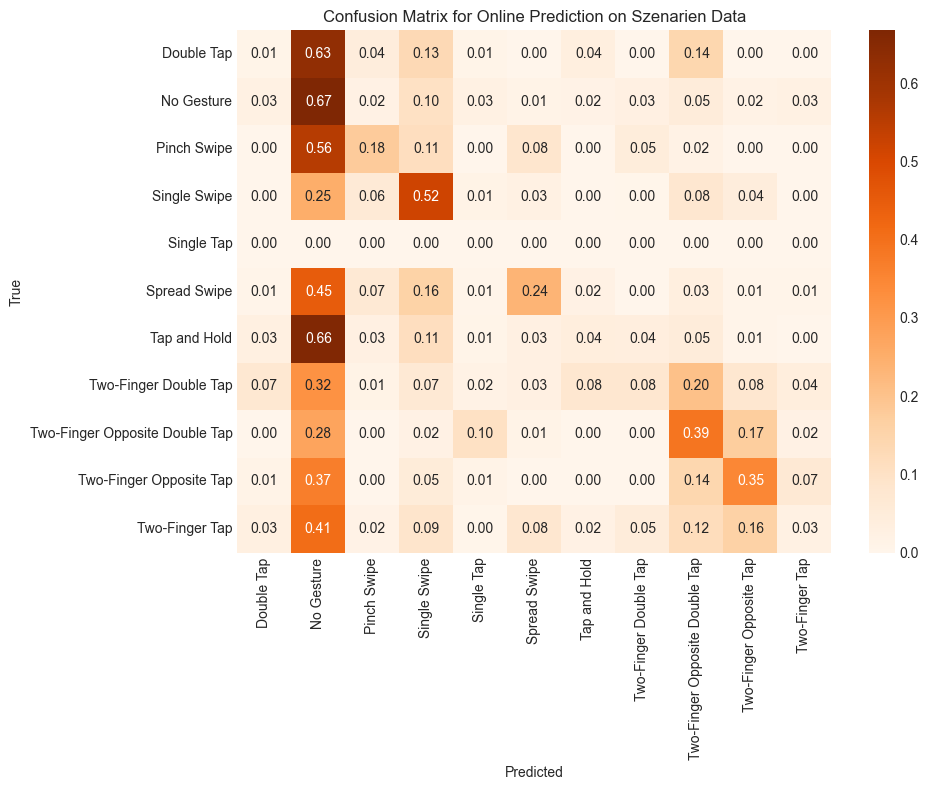

In [126]:
# Optionally restrict to known classes
# map string labels -> indices with same LabelEncoder if classes match
y_true_int = le.transform(all_true)           # if marker labels use same names
y_pred_int = le.transform(all_pred)

used_labels = np.unique(np.concatenate([y_true_int, y_pred_int]))
used_target_names = le.inverse_transform(used_labels)
print(
    classification_report(
        y_true_int,
        y_pred_int,
        labels=used_labels,
        target_names=used_target_names
    )
)

cm = confusion_matrix(y_true_int, y_pred_int, labels=range(len(le.classes_)))
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
cm_norm = np.nan_to_num(cm_norm)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Oranges"
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix for Online Prediction on Szenarien Data")
plt.tight_layout()
plt.show()


In [127]:
# Print the top-k stats
from collections import defaultdict

def top_k_classification_report(
    y_true,
    y_proba,
    k=3,
    class_names=None
):
    n_classes = y_proba.shape[1]
    top_k_preds = np.argsort(y_proba, axis=1)[:, -k:]

    support = defaultdict(int)
    tp = defaultdict(int)
    pred_count = defaultdict(int)

    for i, true_cls in enumerate(y_true):
        support[true_cls] += 1

        for pred_cls in top_k_preds[i]:
            pred_count[pred_cls] += 1
            if pred_cls == true_cls:
                tp[pred_cls] += 1

    rows = []

    for cls in range(n_classes):
        sup = support[cls]
        if sup == 0:
            precision = recall = f1 = 0.0
        else:
            precision = tp[cls] / pred_count[cls] if pred_count[cls] > 0 else 0.0
            recall = tp[cls] / sup
            f1 = (
                2 * precision * recall / (precision + recall)
                if (precision + recall) > 0
                else 0.0
            )

        name = class_names[cls] if class_names is not None else str(cls)
        rows.append((name, precision, recall, f1, sup))

    # calculate averages (macro and weighted)
    for avg_type in ['macro avg', 'weighted avg']:
        # exclude the previous avg from the rows
        filtered_rows = [row for row in rows if row[0] not in ['macro avg', 'weighted avg']]
        if avg_type == 'macro avg':
            precision = np.mean([row[1] for row in filtered_rows])
            recall = np.mean([row[2] for row in filtered_rows])
            f1 = np.mean([row[3] for row in filtered_rows])
            sup = np.sum([row[4] for row in filtered_rows])
        else:
            total_sup = np.sum([row[4] for row in filtered_rows])
            precision = np.sum([row[1] * row[4] for row in filtered_rows]) / total_sup if total_sup > 0 else 0.0
            recall = np.sum([row[2] * row[4] for row in filtered_rows]) / total_sup if total_sup > 0 else 0.0
            f1 = np.sum([row[3] * row[4] for row in filtered_rows]) / total_sup if total_sup > 0 else 0.0
            sup = total_sup
        rows.append((avg_type, precision, recall, f1, sup))

    return rows

In [128]:
top1 = top_k_classification_report(
    y_true_int,
    all_probas,
    k=1,
    class_names=le.classes_
)

top3 = top_k_classification_report(
    y_true_int,
    all_probas,
    k=3,
    class_names=le.classes_
)

print(
    f"{'Class':35s}"
    f"{'P@1':>6s}{'R@1':>6s}{'F1@1':>7s} | "
    f"{'P@3':>6s}{'R@3':>6s}{'F1@3':>7s}{'Sup':>6s}"
)

for (c1, p1, r1, f1, sup), (_, p3, r3, f3, _) in zip(top1, top3):
    print(
        f"{c1:35s}"
        f"{p1:6.2f}{r1:6.2f}{f1:7.2f} | "
        f"{p3:6.2f}{r3:6.2f}{f3:7.2f}{sup:6d}"
    )

Class                                 P@1   R@1   F1@1 |    P@3   R@3   F1@3   Sup
Double Tap                           0.02  0.01   0.01 |   0.01  0.01   0.01   113
No Gesture                           0.27  0.67   0.38 |   0.21  0.87   0.34   391
Pinch Swipe                          0.23  0.18   0.20 |   0.12  0.59   0.19   106
Single Swipe                         0.44  0.52   0.47 |   0.19  0.83   0.31   273
Single Tap                           0.00  0.00   0.00 |   0.00  0.00   0.00     0
Spread Swipe                         0.54  0.24   0.33 |   0.33  0.53   0.41   258
Tap and Hold                         0.26  0.04   0.07 |   0.30  0.72   0.42   301
Two-Finger Double Tap                0.23  0.08   0.12 |   0.23  0.34   0.27   152
Two-Finger Opposite Double Tap       0.18  0.39   0.25 |   0.10  0.46   0.17    87
Two-Finger Opposite Tap              0.26  0.35   0.30 |   0.16  0.73   0.27    92
Two-Finger Tap                       0.19  0.03   0.04 |   0.26  0.24   0.25   238
macr

In [129]:
# Test with szenarios, but give a whole marker_label group at once to check if the classification would work with the correct windowing strategy

# Put all group_ids in windows
windows = []
window_lables = []
meta_data = []
for gid, gdf in szenarien_feature_df.groupby("group_id"):
    X_window = gdf[szenarien_feature_columns].to_numpy(dtype="float32")      # (T, D)
    windows.append(X_window)
    label = gdf["marker_label"].iloc[0]
    window_lables.append(label if label is not None else "No Gesture")
    meta_data.append({
        "session_task_id": gdf["session_task_id"].iloc[0],
        "participant_id": gdf["participant_id"].iloc[0],
        "group_id": gid
    })

print(f"Created {len(windows)} windows from Szenarien data for group_id prediction.")

Created 319 windows from Szenarien data for group_id prediction.


In [130]:
# Print min and max length of windows
window_lengths = [w.shape[0] for w in windows]
print(f"Window lengths: min={min(window_lengths)}, max={max(window_lengths)}")
# Print count of labels
label_counts = pd.Series(window_lables).value_counts()
print("Window label counts:")
for label, count in label_counts.items():
    print(f"  {label}: {count}")

Window lengths: min=4, max=940
Window label counts:
  No Gesture: 174
  Two-Finger Tap: 29
  Single Swipe: 25
  Spread Swipe: 18
  Two-Finger Double Tap: 15
  Two-Finger Opposite Double Tap: 14
  Tap and Hold: 13
  Two-Finger Opposite Tap: 13
  Double Tap: 11
  Pinch Swipe: 7


In [131]:
# Predict each window
all_window_true = []
all_window_pred = []
all_window_proba = []

for X_window, true_label in zip(windows, window_lables):
    X_batch = pad_sequences(
        [X_window],
        maxlen=406,
        dtype="float32",
        padding="pre",
        truncating="pre",
        value=0.0
    )
    proba = model.predict(X_batch, verbose=0)[0]
    
    all_window_proba.append(proba)

    cls_idx = np.argmax(proba)
    conf = proba[cls_idx]
    pred_label = le.classes_[cls_idx] if conf >= threshold else "No Gesture"

    all_window_true.append(true_label)
    all_window_pred.append(pred_label)
# Print unique all_window_true and all_window_pred labels
all_window_true = np.array(all_window_true)
all_window_pred = np.array(all_window_pred)
all_window_proba = np.array(all_window_proba)
unique_window_true_labels = np.unique(all_window_true)
unique_window_pred_labels = np.unique(all_window_pred)
print(f"Unique true window labels: ({len(unique_window_true_labels)}) {unique_window_true_labels}")
print(f"Unique predicted window labels: ({len(unique_window_pred_labels)}) {unique_window_pred_labels}")

Unique true window labels: (10) ['Double Tap' 'No Gesture' 'Pinch Swipe' 'Single Swipe' 'Spread Swipe'
 'Tap and Hold' 'Two-Finger Double Tap' 'Two-Finger Opposite Double Tap'
 'Two-Finger Opposite Tap' 'Two-Finger Tap']
Unique predicted window labels: (11) ['Double Tap' 'No Gesture' 'Pinch Swipe' 'Single Swipe' 'Single Tap'
 'Spread Swipe' 'Tap and Hold' 'Two-Finger Double Tap'
 'Two-Finger Opposite Double Tap' 'Two-Finger Opposite Tap'
 'Two-Finger Tap']


                                precision    recall  f1-score   support

                    Double Tap       0.17      0.09      0.12        11
                    No Gesture       0.79      0.82      0.80       174
                   Pinch Swipe       0.57      0.57      0.57         7
                  Single Swipe       0.56      0.76      0.64        25
                    Single Tap       0.00      0.00      0.00         0
                  Spread Swipe       0.67      0.67      0.67        18
                  Tap and Hold       0.25      0.08      0.12        13
         Two-Finger Double Tap       0.75      0.40      0.52        15
Two-Finger Opposite Double Tap       0.46      0.79      0.58        14
       Two-Finger Opposite Tap       0.24      0.46      0.32        13
                Two-Finger Tap       0.80      0.28      0.41        29

                      accuracy                           0.66       319
                     macro avg       0.48      0.45      0.43 

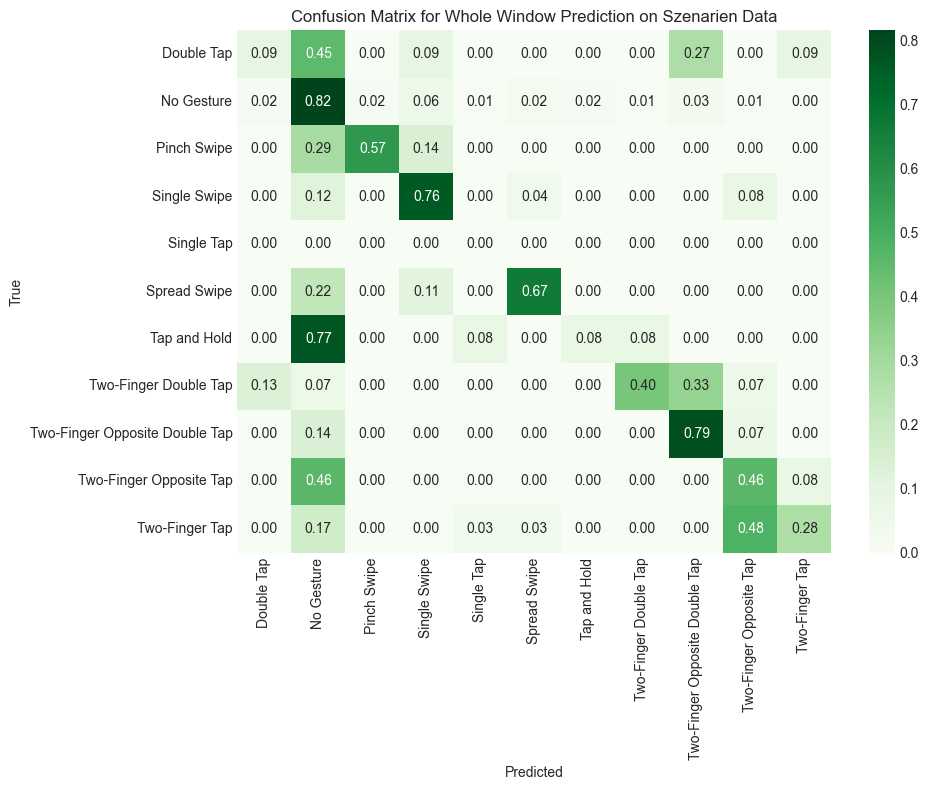

In [132]:
# Print confusion matrix and classification report for window predictions
y_window_true_int = le.transform(all_window_true)           # if marker labels use same names
y_window_pred_int = le.transform(all_window_pred)

used_labels_window = np.unique(np.concatenate([y_window_true_int, y_window_pred_int]))
used_target_names_window = le.inverse_transform(used_labels_window)
print(
    classification_report(
        y_window_true_int,
        y_window_pred_int,
        labels=used_labels_window,
        target_names=used_target_names_window
    )
)

cm_window = confusion_matrix(y_window_true_int, y_window_pred_int, labels=range(len(le.classes_)))
cm_window_norm = cm_window.astype('float') / cm_window.sum(axis=1)[:, np.newaxis]
cm_window_norm = np.nan_to_num(cm_window_norm)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_window_norm,
    annot=True,
    fmt=".2f",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Greens"
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix for Whole Window Prediction on Szenarien Data")
plt.tight_layout()
plt.show()

In [133]:
top1 = top_k_classification_report(
    y_window_true_int,
    all_window_proba,
    k=1,
    class_names=le.classes_
)

top3 = top_k_classification_report(
    y_window_true_int,
    all_window_proba,
    k=3,
    class_names=le.classes_
)

print(
    f"{'Class':35s}"
    f"{'P@1':>6s}{'R@1':>6s}{'F1@1':>7s} | "
    f"{'P@3':>6s}{'R@3':>6s}{'F1@3':>7s}{'Sup':>6s}"
)

for (c1, p1, r1, f1, sup), (_, p3, r3, f3, _) in zip(top1, top3):
    print(
        f"{c1:35s}"
        f"{p1:6.2f}{r1:6.2f}{f1:7.2f} | "
        f"{p3:6.2f}{r3:6.2f}{f3:7.2f}{sup:6d}"
    )

Class                                 P@1   R@1   F1@1 |    P@3   R@3   F1@3   Sup
Double Tap                           0.17  0.09   0.12 |   0.05  0.09   0.06    11
No Gesture                           0.79  0.82   0.80 |   0.65  0.93   0.76   174
Pinch Swipe                          0.57  0.57   0.57 |   0.09  0.86   0.17     7
Single Swipe                         0.56  0.76   0.64 |   0.12  0.96   0.22    25
Single Tap                           0.00  0.00   0.00 |   0.00  0.00   0.00     0
Spread Swipe                         0.67  0.67   0.67 |   0.33  0.94   0.49    18
Tap and Hold                         0.25  0.08   0.12 |   0.10  0.69   0.18    13
Two-Finger Double Tap                0.75  0.40   0.52 |   0.35  0.87   0.50    15
Two-Finger Opposite Double Tap       0.46  0.79   0.58 |   0.22  0.93   0.36    14
Two-Finger Opposite Tap              0.24  0.46   0.32 |   0.09  0.92   0.17    13
Two-Finger Tap                       0.80  0.28   0.41 |   0.53  0.69   0.60    29
macr

In [134]:
import winsound

winsound.MessageBeep()  # system default sound